In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import h5py

import re
import os
from glob import glob

from hifast.baseline import get_baseline
from hifast.util import extend_Trues

In [2]:
f= h5py.File('../test/data/G15_drift_5_arcdrift-M02_W-20200606-specs_T.hdf5','r')

In [4]:
# 如果 mjd 不是 顺序，先 按时间排序，
ind_sort = np.argsort(f['mjd'])

T2p= f['T'][()][ind_sort]

freq = f['freq'][()]

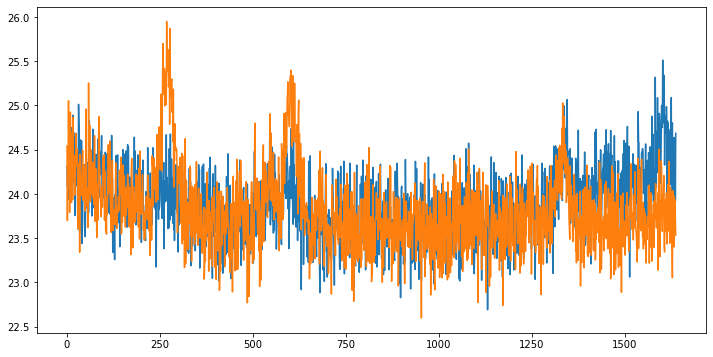

In [5]:
plt.figure(figsize=(12,6))
plt.plot(T2p[200])

(1638, 2)


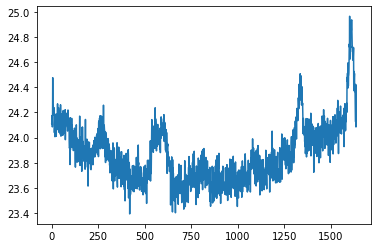

In [48]:
# 选几条合并后
spec = np.mean(T2p[200:210], axis=0, dtype='float64')
print(spec.shape)

# 用 XX 偏振
spec = spec[:,0]
plt.plot(spec)

## Remove "polynomial" baseline

In [49]:
get_baseline?

Signature:
get_baseline(
    x,
    ys,
    axis=None,
    *,
    s_method=None,
    s_sigma=None,
    average_every=None,
    exclude=None,
    verbose=False,
    method='arPLS',
    bl_para=None,
    return_f=False,
)
Docstring:
subtract the baseline of spectra with XX and YY polar.
Parameters：
---------------
x: array, shape (n,); freq or vel. 
ys: array, T or Jy
axis: axis along fitting baseline
s_sigma, s_method: if s_sigma is not None, smoothing ys along axis using s_method ('gaussian' or 'boxcar')
File:      ~/anaconda3/lib/python3.7/site-packages/hifast-0+untagged.2.g0c09ec8-py3.7-linux-x86_64.egg/hifast/baseline.py
Type:      function


get_baseline: 迭代(加权)拟合基线。

拟合基线然后 比较基线和数据 调整每个点的权重后再次拟合，依此迭代

参数:
* 第一个(x)为 *频率* 或者 *速度* 或者 *一个等间隔递增或递减的数组（比如 np.arange(m) )*。shape 为 (m,)
* 第二个(ys)为温度或者流量，与第三个(axis)参数联用
  <br/> 如果ys的shape为(m,),则axis为0
  <br/> 如果ys的shape为(n, m, 2),则axis为1
  <br/> 如果ys的shape为(m,2),则axis为0
  <br/> ...

先预处理后拟合基线;
* s_method: str; 
  <br/> 平滑谱线，方法有'gaussian': 高斯平滑（sigam用s_sigma来设置）, 'median': moving median (每s_sigma个点求median)
* s_sigma: int; 
  <br/> 平滑大小
* average_every: int; 
  <br/> 每X个点平均以合并通道提高信噪比


拟合时的参数：
* exclude: 数组，里面的元素为 True或False, shape与ys一致。True对应的ys里的元素在整个迭代过程中都不会使用（即权重一直为0）.
* bl_para: dict; 搭配method设置
* method: str; 拟合基线的方法：
  * arPLS, srPLS: 分别适用与 只有 正向峰值 和 正向负向峰值都有 的情况。srPLS的效果较arPLS的差
    
    bl_para中可添加的量：
    * lam: 平滑尺度；效果见示例
    * niter: 最多调整权重迭代的次数，默认100
  * Chebyshev, poly: 两种多项式拟合方法：
    
    bl_para中可添加的量：
    * deg: 多项式的次数(阶数)
    * sym: 是否对称调整权重，设为False适用于只有正向峰值 的情况，设为True适用 正向负向峰值都有 的情况。默认为False
    * niter: 最多调整权重迭代的次数，默认100
  * sin_poly: 多个sine加多项式。拟合非常依赖 频率的初始值。*这个方法只会拟合一次，不会调整权重 重新拟合*。
    bl_para中可添加的量：
    * f: float或者list。拟合的sine函数的频率初始值。
    * deg: 多项式的次数(阶数)。最好不超过2
    
    
与hifast.cli_baseline_mpi的参数对应:

|get_baseline| hifast.cli_baseline_mpi  | 
|---|---|
| s_method | --s_method_freq|
| s_sigma | --s_sigma_freq|
| average_every | --average_every_freq|
| method  | --method  |
| lam in bl_para|  --lam |
| deg in bl_para|  --deg |
| niter in bl_para|  --niter |
| f in bl_para|  --sin_f

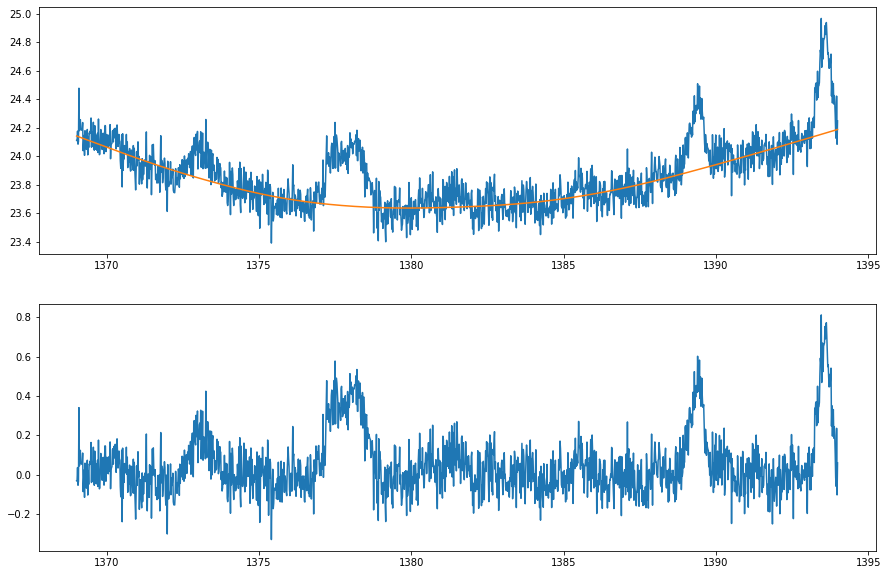

In [56]:
# fit
method= 'arPLS'
kwargs={}
kwargs['lam']= 1e7
kwargs['deg']= 2
kwargs['niter']= 100

fig,axs= plt.subplots(2,1,figsize=(15,10),)
bl1 = get_baseline(freq, spec, axis=0, average_every=2, method=method, bl_para=kwargs, verbose=False)
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl1)

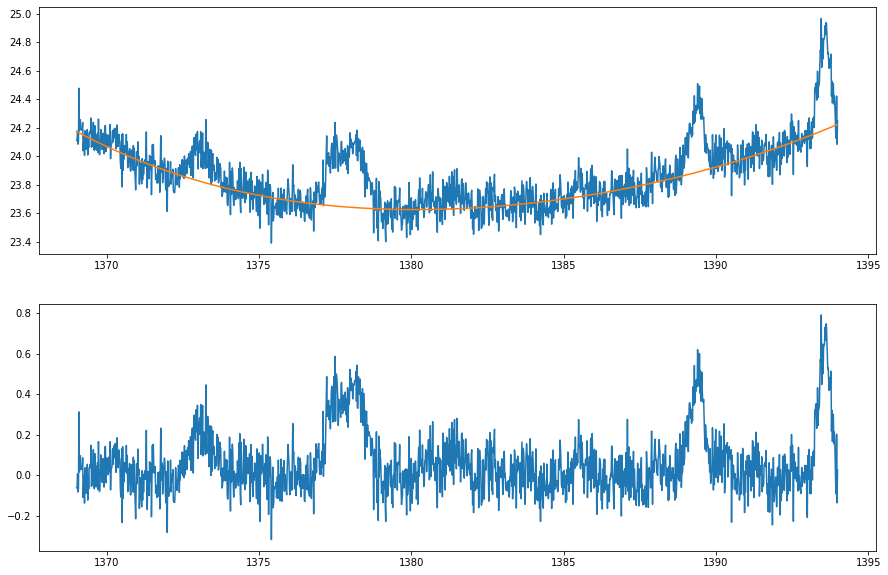

In [57]:
# fit
method= 'Chebyshev'
kwargs={}
kwargs['deg']= 4
kwargs['niter']= 100

fig,axs= plt.subplots(2,1,figsize=(15,10),)
bl1 = get_baseline(freq, spec, axis=0, method=method, bl_para=kwargs, verbose=False)
# plot Polar XX
ax = axs[0]
ax.plot(freq, spec)
ax.plot(freq, bl1)
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec-bl1)

## remove sine baseline

In [58]:
# 先减去上一步拟合处的基线
spec_bld = spec - bl1
# 生成 exclude点
spec_tmp= spec_bld
exclude = abs(spec_tmp) > np.diff(np.percentile(spec_tmp, [16,84]))*2
exclude = extend_Trues(exclude, axis=0, ext_frac=1/3, ext_add=50)

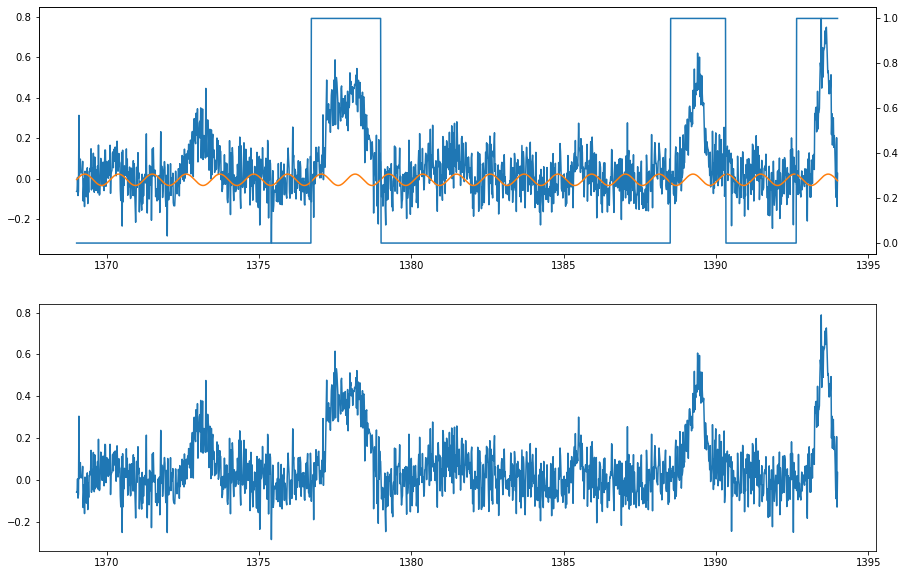

In [59]:
method= 'sin_poly'
kwargs={}
kwargs['f']= 1/1.08
kwargs['deg']= 2

fig,axs= plt.subplots(2,1,figsize=(15,10),)
bl2 = get_baseline(freq, spec_bld, axis=0, exclude=exclude, average_every=2, method=method, bl_para=kwargs, verbose=False)

# plot Polar XX
ax = axs[0]
ax.plot(freq, spec_bld)
ax.plot(freq, bl2)
ax = ax.twinx()
ax.plot(freq, exclude)
# plot baselined YY and YY
ax = axs[1]
ax.plot(freq, spec_bld-bl2)